In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_parquet("../04_wnir.parquet")

In [9]:
df.shape

(1336403, 22)

Shape after dropna: (693816, 9)
Shape after sampling: (10000, 9)


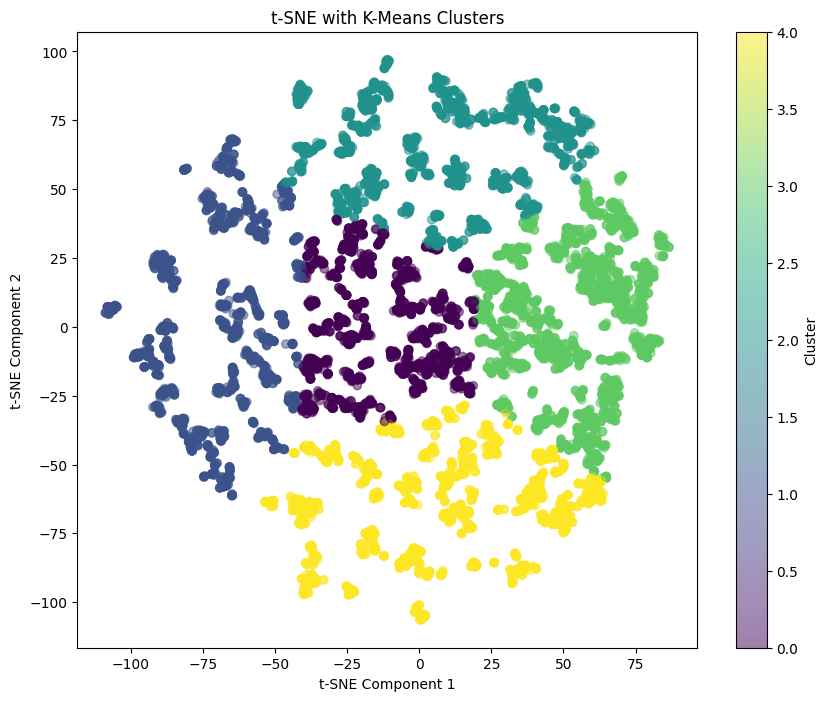

In [ ]:
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select numerical columns for UMAP (excluding non-numerical like address, date, etc.)
numerical_cols = [
    "longitude",
    "latitude",
    "area",
    "room_count",
    # "floor",
    # "floor_count",
    # "ceiling_height",
    # "build_year",
    # "price",
    # "price_per_square_meter",
    # "discount_index",
    "price_per_square_meter_normalized",
    "price_normalized",
    "wnir",
    "wnir_neighbours_count",
    "primary_to_secondary_wnir_ratio",
]
df_numerical = df[numerical_cols].dropna()
print("Shape after dropna:", df_numerical.shape)

# Sample for UMAP efficiency
sample_size = min(10000, len(df_numerical))
df_sample = df_numerical.sample(n=sample_size, random_state=42)
print("Shape after sampling:", df_sample.shape)

# Standardize the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_sample)

# Apply UMAP
umap_reducer = umap.UMAP(n_components=2, random_state=42)
umap_components = umap_reducer.fit_transform(df_scaled)

# Create a DataFrame with the UMAP components
umap_df = pd.DataFrame(data=umap_components, columns=["UMAP1", "UMAP2"])

# Clustering on UMAP components
kmeans = KMeans(n_clusters=5, random_state=42)  # Adjust n_clusters as needed
clusters = kmeans.fit_predict(umap_df)

# Plot UMAP with clusters
plt.figure(figsize=(10, 8))
plt.scatter(umap_df["UMAP1"], umap_df["UMAP2"], c=clusters, cmap="viridis", alpha=0.5)
plt.title("UMAP with K-Means Clusters")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.colorbar(label="Cluster")
plt.show()